# Reaction Kinetics with Recurrent Neural Networks
In this lab, we model the following reaction
$$\mathrm{C_2H_5OH} \xrightarrow{k_1} \mathrm{CH_3CHO}
\xrightarrow{k_2} \mathrm{CH_2O}
\xrightarrow{k_3} \mathrm{CO}
\xrightarrow{k_4} \mathrm{CO_2} $$

We will use a `csv` file with time steps (s) and concentrations (mol/L) of the above species.

In [1]:
!wget -O reaction_kinetics.csv -q "https://github.com/SunLab-Rutgers/chem542_CDS/raw/main/labs/lab13/data/reaction_kinetics.csv"

In [2]:
# import libraries
import torch
import torch.nn as nn
import pandas as pd

## Preprocessing data

In [4]:
df = pd.read_csv("reaction_kinetics.csv", index_col=False)
df.head()

,time,ethanol,acetaldehyde,formaldehyde,CO,CO2
0,0.000000,1.010941,0.005494,0.009944,0.006452,0.006133
1,0.050251,0.928412,0.035243,0.007281,-0.014928,-0.000617
2,0.100503,0.906314,0.105358,0.021033,-0.000100,-0.017464
3,0.150754,0.821186,0.141687,0.016872,0.016454,-0.023747
4,0.201005,0.786030,0.200879,-0.018657,0.005457,0.000064


In [5]:
# Extract concentrations only
species = ["ethanol", "acetaldehyde", "formaldehyde", "CO", "CO2"]
X = df[species].values
print(f"Number of time steps: {len(df)}")

Number of time steps: 200


We will use the first $(T-1)$ steps to train a recurrent neural network (RNN), and the last $(T-1)$ steps as the targets.

In [9]:
X_t = X[:-1] # input
Y_t = X[1:] # reference
print(f"Input size: {len(X_t)}")
print(f"Output size: {len(Y_t)}")

Input size: 199
Output size: 199


In [10]:
# Convert to tensors
X_t = torch.tensor(X_t, dtype=torch.float32)
Y_t = torch.tensor(Y_t, dtype=torch.float32)

print(f"Input shape: {X_t.shape}")
print(f"Output shape: {Y_t.shape}")

# Add sequence dimension: (batch, seq_len, features)
# Here seq_len = 1, so we simply use unsqueeze(<dim>)
X_t = X_t.unsqueeze(1) # unsqueeze(1) means adding an extra dimension to the column
Y_t = Y_t.unsqueeze(1)

# print the shape after adding a new |dimension
print(f"Input shape unsqueezed: {X_t.shape}")
print(f"Output shape unsqueezed: {Y_t.shape}")

Input shape: torch.Size([199, 5])
Output shape: torch.Size([199, 5])
Input shape unsqueezed: torch.Size([199, 1, 5])
Output shape unsqueezed: torch.Size([199, 1, 5])


## Define the RNN class

In [11]:
class KineticsRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=None):
        super().__init__()
        if output_dim is None:
            output_dim = input_dim # usually the input and output has the same dimension in RNN

        # instead of using nn.Sequential for FNN, we use nn.RNN here
        self.rnn = nn.RNN(
            input_size=input_dim,
            hidden_size=hidden_dim,
            batch_first=True # the batch size (number of time steps) comes first in the input shape
        )

        # infer the output from the last hidden state
        self.fc = nn.Linear(hidden_dim, output_dim) # fc: fully connected layer

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        out, h = self.rnn(x)
        # out: (batch, seq_len, hidden_dim)
        y = self.fc(out)
        return y

## Train the RNN model with the same routine for FNN

In [12]:
my_model = KineticsRNN(
    input_dim=5,
    hidden_dim=32,
    output_dim=5
)

In [13]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(my_model.parameters(), lr=1e-3)

n_epochs = 1000

for epoch in range(n_epochs):
    optimizer.zero_grad()

    y_pred = my_model(X_t)
    loss = criterion(y_pred, Y_t)

    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")

Epoch 0, Loss = 0.075946
Epoch 100, Loss = 0.005055
Epoch 200, Loss = 0.001394
Epoch 300, Loss = 0.000855
Epoch 400, Loss = 0.000548
Epoch 500, Loss = 0.000392
Epoch 600, Loss = 0.000321
Epoch 700, Loss = 0.000288
Epoch 800, Loss = 0.000270
Epoch 900, Loss = 0.000257


## Examine the output

In [14]:
from matplotlib import pyplot as plt
import numpy as np

In [16]:
with torch.no_grad():
    Y_t_pred = my_model(X_t)
    Y_t_pred = Y_t_pred.detach().numpy()

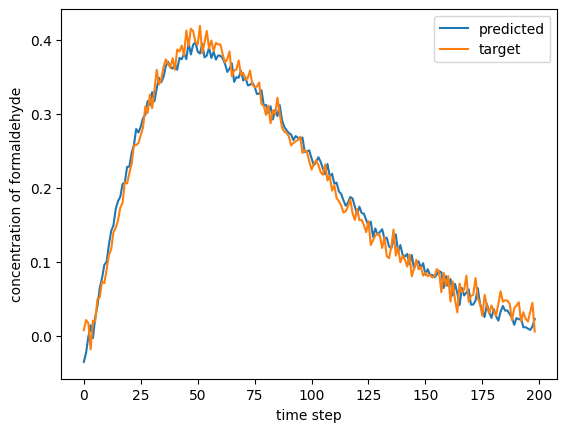

In [18]:
time_step = np.arange(len(df)-1)
species_idx = 2
plt.plot(time_step, Y_t_pred[:, 0, species_idx], label="predicted")
plt.plot(time_step, Y_t[:, 0, species_idx], label="target")
plt.xlabel("time step")
plt.ylabel(f"concentration of {species[species_idx]}")
plt.legend()

# Using LSTM model
We will define an LSTM model to do the same task.

In [19]:
class KineticsLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=None, num_layers=1):
        super().__init__()
        if output_size is None:
            output_size = input_size

        self.hidden_size = hidden_size
        self.num_layers = num_layers # number of layers to evaluate the hidden states

        # LSTM
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        # Readout layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)

        batch_size = x.size(0)

        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)

        # LSTM forward pass
        out, (hT, cT) = self.lstm(x, (h0, c0)) # output, hidden state and cells state

        # Map to concentrations
        y_pred = self.fc(out)    # (batch, 1, output_size)

        return y_pred

### Same training routine, just change the model we use

In [20]:
my_lstm_model = KineticsLSTM(
    input_size=5,
    hidden_size=32,
    output_size=5
)

In [21]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(my_lstm_model.parameters(), lr=1e-3)

n_epochs = 1000

for epoch in range(n_epochs):
    optimizer.zero_grad()

    y_pred = my_lstm_model(X_t)
    loss = criterion(y_pred, Y_t)

    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")

Epoch 0, Loss = 0.101101
Epoch 100, Loss = 0.021177
Epoch 200, Loss = 0.006383
Epoch 300, Loss = 0.002023
Epoch 400, Loss = 0.001295
Epoch 500, Loss = 0.000837
Epoch 600, Loss = 0.000492
Epoch 700, Loss = 0.000354
Epoch 800, Loss = 0.000320
Epoch 900, Loss = 0.000309


Same visualization step

In [22]:
with torch.no_grad():
    Y_t_pred = my_lstm_model(X_t)
    Y_t_pred = Y_t_pred.detach().numpy()

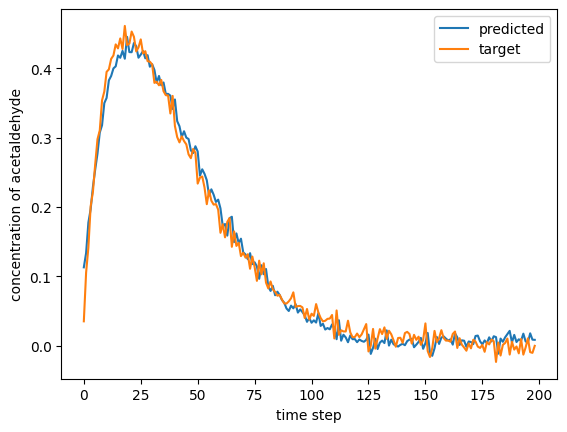

In [23]:
time_step = np.arange(len(df)-1)
species_idx = 1
plt.plot(time_step, Y_t_pred[:, 0, species_idx], label="predicted")
plt.plot(time_step, Y_t[:, 0, species_idx], label="target")
plt.xlabel("time step")
plt.ylabel(f"concentration of {species[species_idx]}")
plt.legend()